# Laboratorio 8

- Mathew Alexander Cordero Aquino 22982
- Pedro Pablo Guzman Mayen  22111

# Investigación Previa



## Modelo VGG16:

Es un modelo entrenado con más de 1000 clases mediante *fine tuning*. En realidad, es una enorme red CNN conformada por 16 capas convolucionales que se encargan de extraer características de las imágenes y clasificarlas.

**Layers in the CNN:**

**Primera capa: Convolutional Layers (conv1 — conv5):**

* Estas capas son las responsables de detectar características en la imagen de entrada, como bordes, texturas y patrones.
* Cada capa convolucional aplica una serie de filtros a la imagen, generando *feature maps*.
* Los números junto a cada capa (por ejemplo, 224x224x64, 112x112x128) indican las dimensiones de los *feature maps*: las dos primeras cifras representan el alto y ancho, y la tercera el número de canales o filtros.

**Segunda capa: ReLU (Rectified Linear Unit) Activation:**

* Después de cada convolución, se aplica la función de activación ReLU, que introduce no linealidad al modelo.
* Esto permite que la red aprenda patrones más complejos y no se limite a relaciones lineales.

**Tercera capa: Max Pooling Layers:**

* Estas capas (marcadas en rojo) reducen las dimensiones espaciales de los *feature maps* manteniendo la información más relevante, un proceso conocido como *downsampling*.
* El *max pooling* ayuda a disminuir la complejidad computacional y a que la red sea más robusta ante variaciones espaciales en la entrada.

**Cuarta capa: Fully Connected Layers (fc6 — fc8):**

* Las capas totalmente conectadas (en verde) al final de la red funcionan como el clasificador.
* Estas capas toman las características de alto nivel extraídas por las capas convolucionales y las utilizan para realizar predicciones.
* La primera capa totalmente conectada (*fc6*) cuenta con 4096 neuronas, la segunda (*fc7*) también con 4096, y la última (*fc8*) produce la salida final, normalmente con 1000 clases en el modelo VGG16 original.
* En la práctica, esta última capa se ajusta para coincidir con el número de clases específicas de la tarea que se quiere resolver.




## Dataset CIFAR:

Este es un conjunto de datos con 80 millones de imágenes en miniatura, creado por Alex Krizhevsky, Vinod Nair y Geoffrey Hinton. Dentro de este gran conjunto, el más utilizado para experimentos en visión por computadora es CIFAR-10 (y su versión extendida CIFAR-100).

El conjunto CIFAR-10 contiene imágenes de 10 clases: aviones, automóviles, pájaros, gatos, ciervos, perros, ranas, caballos, barcos y camiones.

- Dimensiones de cada imagen: 32 × 32 píxeles, con 3 canales de color (RGB).

- Tamaño aproximado por imagen: alrededor de 3 KB.

- Número total de imágenes: 60,000.

- Conjunto de entrenamiento: 50,000 imágenes.

- Conjunto de prueba: 10,000 imágenes.

- Resolución y formato: imágenes a color de baja resolución (32×32×3), almacenadas normalmente en formato binario o pickle dentro de archivos .tar o .python.

Estas imágenes fueron seleccionadas para representar distintas categorías comunes del mundo real y son ampliamente utilizadas para probar modelos CNN como VGG16, ResNet o AlexNet, debido a su tamaño manejable y diversidad de clases.



# Implementación

## Evaluación sin entrenamiento adicional

1.   Elemento de la lista
2.   Elemento de la lista









In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [20]:
model = models.vgg16(pretrained=True)


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)


num_classes = 10
batch_size = 64
num_epochs = 8
learning_rate = 0.001

Usando: cuda


In [8]:
transform_test = transforms.Compose([
    transforms.Resize(224),  # VGG16 espera 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Dataset y DataLoader (solo test)

In [9]:
test_dataset = datasets.CIFAR10(root="./data", train=False,
                                download=True, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 47.2MB/s]


In [19]:
model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()


Evaluacion

In [12]:
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


In [13]:
avg_loss = test_loss / len(test_loader)
accuracy = 100 * correct / total

print(f"Pérdida promedio en test: {avg_loss:.4f}")
print(f"Precisión en test: {accuracy:.2f}%")

Pérdida promedio en test: 2.3607
Precisión en test: 8.69%


## Feature Extraction

In [14]:
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [15]:
train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [26]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Congelar TODAS las capas convolucionales
for param in model.features.parameters():
    param.requires_grad = False

# Reemplazar la última capa del clasificador (1000 → 10)
model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=learning_rate)

Entrenar

In [28]:
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(num_epochs):
    # --- Entrenamiento ---
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # --- Evaluación ---
    model.eval()
    test_loss = 0.0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_acc = 100 * correct_test / total_test

    # Guardar métricas por época
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Época [{epoch+1}/{num_epochs}]  "
          f"Loss train: {train_loss:.4f} | Loss test: {test_loss:.4f} | "
          f"Acc train: {train_acc:.2f}% | Acc test: {test_acc:.2f}%")

Época [1/8]  Loss train: 0.6094 | Loss test: 0.4892 | Acc train: 78.74% | Acc test: 82.84%
Época [2/8]  Loss train: 0.5931 | Loss test: 0.4847 | Acc train: 79.43% | Acc test: 82.79%
Época [3/8]  Loss train: 0.5991 | Loss test: 0.4759 | Acc train: 79.61% | Acc test: 83.59%
Época [4/8]  Loss train: 0.5993 | Loss test: 0.4663 | Acc train: 79.66% | Acc test: 83.68%
Época [5/8]  Loss train: 0.5903 | Loss test: 0.4748 | Acc train: 80.03% | Acc test: 83.55%
Época [6/8]  Loss train: 0.5975 | Loss test: 0.4750 | Acc train: 80.04% | Acc test: 83.43%
Época [7/8]  Loss train: 0.5992 | Loss test: 0.4749 | Acc train: 80.07% | Acc test: 83.39%
Época [8/8]  Loss train: 0.5983 | Loss test: 0.4850 | Acc train: 80.08% | Acc test: 83.45%


In [29]:
final_train_loss = train_losses[-1]
final_test_loss = test_losses[-1]
final_train_acc = train_accuracies[-1]
final_test_acc = test_accuracies[-1]

print("\n===== RESULTADOS FINALES =====")
print(f"Loss entrenamiento final: {final_train_loss:.4f}")
print(f"Loss prueba final: {final_test_loss:.4f}")
print(f"Accuracy entrenamiento final: {final_train_acc:.2f}%")
print(f"Accuracy prueba final: {final_test_acc:.2f}%")


===== RESULTADOS FINALES =====
Loss entrenamiento final: 0.5983
Loss prueba final: 0.4850
Accuracy entrenamiento final: 80.08%
Accuracy prueba final: 83.45%


Graficar

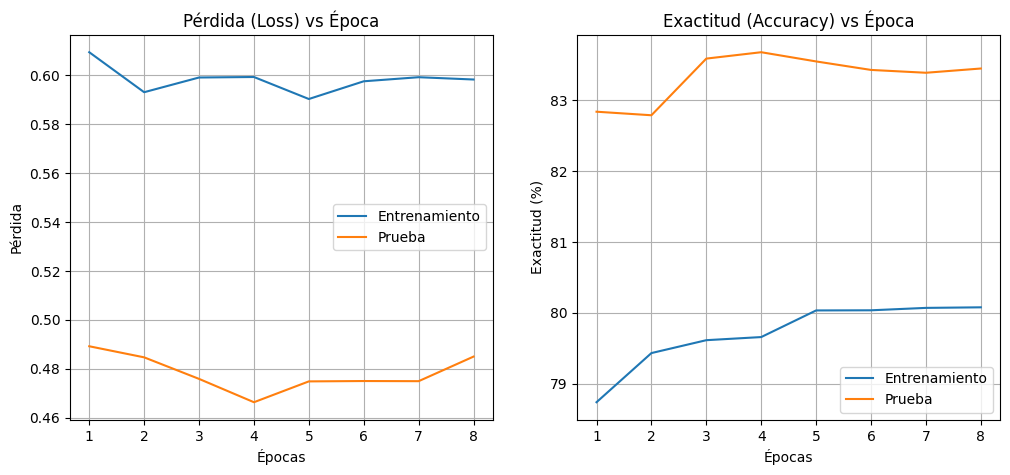

In [30]:
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12,5))

# --- Loss ---
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Entrenamiento')
plt.plot(epochs, test_losses, label='Prueba')
plt.title('Pérdida (Loss) vs Época')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# --- Accuracy ---
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label='Entrenamiento')
plt.plot(epochs, test_accuracies, label='Prueba')
plt.title('Exactitud (Accuracy) vs Época')
plt.xlabel('Épocas')
plt.ylabel('Exactitud (%)')
plt.legend()
plt.grid(True)

plt.show()

## Fine-Tuning

In [31]:
model = models.vgg16(pretrained=True)

for param in model.parameters():
    param.requires_grad = True

num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 10)

model = model.to(device)

# === Optimizador con tasa de aprendizaje reducida ===
# (usualmente más baja porque se entrena todo el modelo)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Criterio de pérdida igual
criterion = nn.CrossEntropyLoss()

Época [1/5] Loss train: 0.5602 | Loss test: 0.2806 | Acc train: 80.83% | Acc test: 90.36%


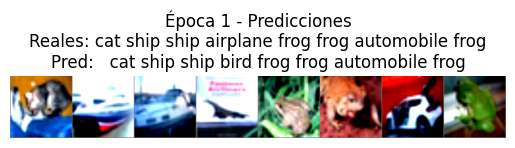

Época [2/5] Loss train: 0.2594 | Loss test: 0.2458 | Acc train: 91.11% | Acc test: 91.61%


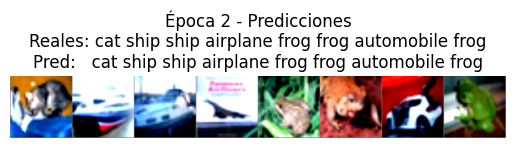

Época [3/5] Loss train: 0.1868 | Loss test: 0.2066 | Acc train: 93.60% | Acc test: 93.02%


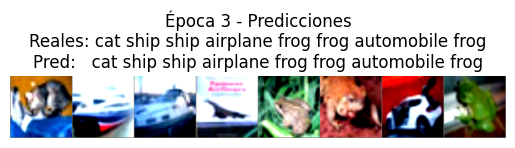

Época [4/5] Loss train: 0.1440 | Loss test: 0.2076 | Acc train: 95.09% | Acc test: 92.89%


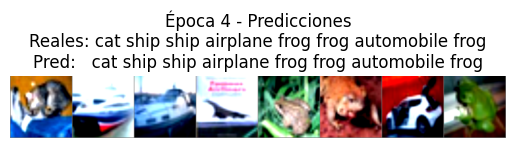

Época [5/5] Loss train: 0.1040 | Loss test: 0.2035 | Acc train: 96.47% | Acc test: 93.12%


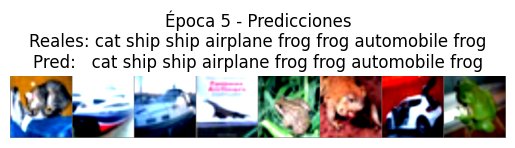

In [33]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title=None):

    img = img / 2 + 0.5  # desnormaliza (por si estaban en [-1, 1])
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()


num_epochs = 5

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(num_epochs):
    # --- ENTRENAMIENTO ---
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # --- EVALUACIÓN ---
    model.eval()
    test_loss = 0.0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_acc = 100 * correct_test / total_test

    # Guardar métricas
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Época [{epoch+1}/{num_epochs}] "
          f"Loss train: {train_loss:.4f} | Loss test: {test_loss:.4f} | "
          f"Acc train: {train_acc:.2f}% | Acc test: {test_acc:.2f}%")

    # --- Mostrar evolución visual de predicciones ---
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    # Seleccionar las primeras 8 imágenes
    imgs_show = images.cpu()[:8]
    labels_show = labels.cpu()[:8]
    preds_show = predicted.cpu()[:8]

    classes = train_dataset.classes
    title = (f"Época {epoch+1} - Predicciones\n" +
             "Reales: " + " ".join(f"{classes[labels_show[j]]}" for j in range(8)) + "\n" +
             "Pred:   " + " ".join(f"{classes[preds_show[j]]}" for j in range(8)))

    imshow(torchvision.utils.make_grid(imgs_show, nrow=8), title=title)


In [35]:
print("\n=== RESULTADOS FINALES ===")
print(f"Última época ({num_epochs}):")
print(f"  Loss de entrenamiento: {train_losses[-1]:.4f}")
print(f"  Loss de prueba: {test_losses[-1]:.4f}")
print(f"  Accuracy de entrenamiento: {train_accuracies[-1]:.2f}%")
print(f"  Accuracy de prueba: {test_accuracies[-1]:.2f}%")


=== RESULTADOS FINALES ===
Última época (5):
  Loss de entrenamiento: 0.1040
  Loss de prueba: 0.2035
  Accuracy de entrenamiento: 96.47%
  Accuracy de prueba: 93.12%


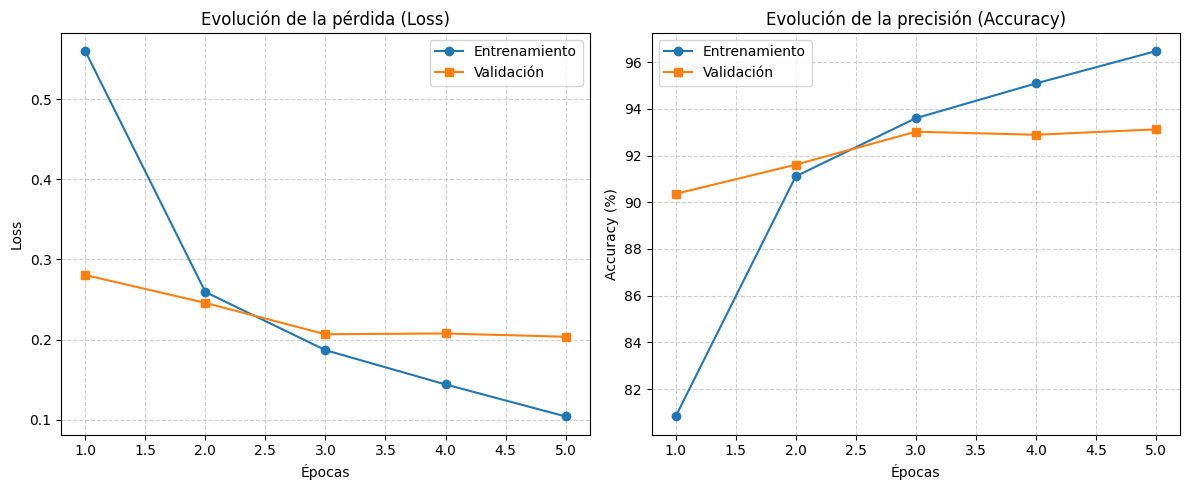

In [34]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# --- Curva de pérdida ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Entrenamiento', marker='o')
plt.plot(epochs, test_losses, label='Validación', marker='s')
plt.title('Evolución de la pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- Curva de precisión ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Entrenamiento', marker='o')
plt.plot(epochs, test_accuracies, label='Validación', marker='s')
plt.title('Evolución de la precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# Evaluación y comparación de resultados




Aquí tienes los resultados organizados en una tabla comparativa:

| **Etapa**                                  | **Pérdida de Entrenamiento** | **Pérdida de Prueba** | **Precisión Entrenamiento (%)** | **Precisión Prueba (%)** |
| ------------------------------------------ | ---------------------------- | --------------------- | ------------------------------- | ------------------------ |
| **Evaluación sin entrenamiento adicional** | –                            | 2.3607                | –                               | 8.69                     |
| **Feature Extraction**                     | 0.5983                       | 0.4850                | 80.08                           | 83.45                    |
| **Fine Tuning (época final)**              | 0.1040                       | 0.2035                | 96.47                           | 93.12                    |


